# Phân tích lựa chọn đặc trưng cơ bản - Baseline

Notebook này thực hiện phân tích cơ bản để xếp hạng tầm quan trọng của từng đặc trưng trong dự đoán tuổi của Abalone.

**Phương pháp:**
- Tương quan Pearson với biến mục tiêu (target)
- Kiểm định thống kê (F-test, Mutual Information)
- P-value để đánh giá ý nghĩa thống kê

## 1. Cài đặt và Import các thư viện

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression, mutual_info_regression, SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Cài đặt hiển thị
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu

In [ ]:
# Đọc dữ liệu gốc
from pathlib import Path

# Thử nhiều đường dẫn tương đối vì thư mục chạy notebook có thể khác nhau
duong_dan_ung_vien = [
    Path("../../data/raw/abalone.csv"),
    Path("../data/raw/abalone.csv"),
    Path("data/raw/abalone.csv"),
    Path("AbaloneAge/data/raw/abalone.csv"),
]

duong_dan_du_lieu = None
for p in duong_dan_ung_vien:
    p_day_du = p.resolve()
    if p_day_du.exists():
        duong_dan_du_lieu = p_day_du
        break

if duong_dan_du_lieu is None:
    raise FileNotFoundError(
        "Không tìm thấy file abalone.csv. Đã thử các đường dẫn: "
        + ", ".join(str(p.resolve()) for p in duong_dan_ung_vien)
    )

df = pd.read_csv(duong_dan_du_lieu, header=None)

# Đặt tên cột
column_names = ['sex', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'rings']
df.columns = column_names

print("Đường dẫn dữ liệu:", duong_dan_du_lieu)
print("Kích thước dữ liệu:", df.shape)
print("\nKiểu dữ liệu:")
print(df.dtypes)
print("\nSố giá trị thiếu:")
print(df.isnull().sum())
print("\n5 dòng đầu tiên:")
df.head()

Đường dẫn dữ liệu: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\data\raw\abalone.csv
Kích thước dữ liệu: (4177, 9)

Kiểu dữ liệu:
sex                object
length            float64
diameter          float64
height            float64
whole_weight      float64
shucked_weight    float64
viscera_weight    float64
shell_weight      float64
rings               int64
dtype: object

Số giá trị thiếu:
sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

5 dòng đầu tiên:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [5]:
# Thống kê cơ bản
print("Thông tin thống kê về biến mục tiêu (rings - tuổi):")
print(df['rings'].describe())
print(f"\nSố loại giới tính: {df['sex'].unique()}")

Thông tin thống kê về biến mục tiêu (rings - tuổi):
count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: rings, dtype: float64

Số loại giới tính: ['M' 'F' 'I']


## 3. Chuẩn bị dữ liệu cho phân tích

In [6]:
# Tách target
X = df.drop('rings', axis=1)
y = df['rings']

# Mã hóa cột 'sex' (danh mục) thành số
le = LabelEncoder()
X_encoded = X.copy()
X_encoded['sex'] = le.fit_transform(X['sex'])

print("Đặc trưng (X):")
print(X_encoded.head())
print(f"\nHình dạng X: {X_encoded.shape}")
print(f"Hình dạng y: {y.shape}")

Đặc trưng (X):
   sex  length  diameter  height  whole_weight  shucked_weight  \
0    2   0.455     0.365   0.095        0.5140          0.2245   
1    2   0.350     0.265   0.090        0.2255          0.0995   
2    0   0.530     0.420   0.135        0.6770          0.2565   
3    2   0.440     0.365   0.125        0.5160          0.2155   
4    1   0.330     0.255   0.080        0.2050          0.0895   

   viscera_weight  shell_weight  
0          0.1010         0.150  
1          0.0485         0.070  
2          0.1415         0.210  
3          0.1140         0.155  
4          0.0395         0.055  

Hình dạng X: (4177, 8)
Hình dạng y: (4177,)


## 4. Phân tích Tương quan (Correlation)

In [7]:
# Tính tương quan Pearson
correlation_with_target = X_encoded.corrwith(y).abs().sort_values(ascending=False)

print("=" * 50)
print("TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (Rings - Tuổi)")
print("=" * 50)
print(correlation_with_target)

# Lưu vào dataframe để dễ so sánh sau
feature_scores = pd.DataFrame({
    'đặc_trưng': correlation_with_target.index,
    'tương_quan': correlation_with_target.values
})

TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (Rings - Tuổi)
shell_weight      0.627574
diameter          0.574660
height            0.557467
length            0.556720
whole_weight      0.540390
viscera_weight    0.503819
shucked_weight    0.420884
sex               0.034627
dtype: float64


## 5. Kiểm định Thống kê - F-test Regression

In [8]:
# F-test cho hồi quy
f_scores, f_pvalues = f_regression(X_encoded, y)

f_test_results = pd.DataFrame({
    'đặc_trưng': X_encoded.columns,
    'f_score': f_scores,
    'p_value': f_pvalues
}).sort_values('f_score', ascending=False)

print("\n" + "=" * 60)
print("KIỂM ĐỊNH THỐNG KÊ: F-test (Hồi quy)")
print("=" * 60)
print(f_test_results.to_string(index=False))
print("\nGhi chú: P-value < 0.05 = Có ý nghĩa thống kê")


KIỂM ĐỊNH THỐNG KÊ: F-test (Hồi quy)
     đặc_trưng     f_score       p_value
  shell_weight 2712.724757  0.000000e+00
      diameter 2058.519849  0.000000e+00
        height 1882.482838  0.000000e+00
        length 1875.169489  0.000000e+00
  whole_weight 1722.067593 1.888678e-315
viscera_weight 1420.268451 8.574726e-268
shucked_weight  898.785933 5.087464e-179
           sex    5.011887  2.522634e-02

Ghi chú: P-value < 0.05 = Có ý nghĩa thống kê


## 6. Phân tích Thông tin Lẫn Nhau (Mutual Information)

In [9]:
# Mutual Information
mi_scores = mutual_info_regression(X_encoded, y, random_state=42)

mi_results = pd.DataFrame({
    'đặc_trưng': X_encoded.columns,
    'mutual_information': mi_scores
}).sort_values('mutual_information', ascending=False)

print("\n" + "=" * 60)
print("THÔNG TIN LẫN NHAU (Mutual Information)")
print("=" * 60)
print(mi_results.to_string(index=False))
print("\nGhi chú: Giá trị cao hơn = Mối quan hệ mạnh hơn với mục tiêu")


THÔNG TIN LẫN NHAU (Mutual Information)
     đặc_trưng  mutual_information
  shell_weight            0.458525
        height            0.399383
  whole_weight            0.391736
      diameter            0.386064
viscera_weight            0.373845
        length            0.356366
shucked_weight            0.334224
           sex            0.134593

Ghi chú: Giá trị cao hơn = Mối quan hệ mạnh hơn với mục tiêu


## 7. Bảng So sánh Tất cả Phương pháp

In [10]:
# Hợp nhất tất cả kết quả
comparison_df = feature_scores.copy()
comparison_df = comparison_df.merge(
    f_test_results[['đặc_trưng', 'f_score', 'p_value']],
    left_on='đặc_trưng', right_on='đặc_trưng'
)
comparison_df = comparison_df.merge(
    mi_results[['đặc_trưng', 'mutual_information']],
    left_on='đặc_trưng', right_on='đặc_trưng'
)

# Thêm cột xếp hạng
comparison_df['xếp_hạng_tương_quan'] = comparison_df['tương_quan'].rank(ascending=False).astype(int)
comparison_df['xếp_hạng_f_score'] = comparison_df['f_score'].rank(ascending=False).astype(int)
comparison_df['xếp_hạng_mi'] = comparison_df['mutual_information'].rank(ascending=False).astype(int)
comparison_df['xếp_hạng_trung_bình'] = comparison_df[['xếp_hạng_tương_quan', 'xếp_hạng_f_score', 'xếp_hạng_mi']].mean(axis=1).round(1)

# Sắp xếp theo xếp hạng trung bình
comparison_df = comparison_df.sort_values('xếp_hạng_trung_bình')

print("\n" + "=" * 100)
print("BẢNG SO SÁNH - XẾP HẠNG TẤT CẢ PHƯƠNG PHÁP")
print("=" * 100)
print(comparison_df.to_string(index=False))


BẢNG SO SÁNH - XẾP HẠNG TẤT CẢ PHƯƠNG PHÁP
     đặc_trưng  tương_quan     f_score       p_value  mutual_information  xếp_hạng_tương_quan  xếp_hạng_f_score  xếp_hạng_mi  xếp_hạng_trung_bình
  shell_weight    0.627574 2712.724757  0.000000e+00            0.458525                    1                 1            1                  1.0
      diameter    0.574660 2058.519849  0.000000e+00            0.386064                    2                 2            4                  2.7
        height    0.557467 1882.482838  0.000000e+00            0.399383                    3                 3            2                  2.7
  whole_weight    0.540390 1722.067593 1.888678e-315            0.391736                    5                 5            3                  4.3
        length    0.556720 1875.169489  0.000000e+00            0.356366                    4                 4            6                  4.7
viscera_weight    0.503819 1420.268451 8.574726e-268            0.373845        

## 8. Trực quan hóa kết quả

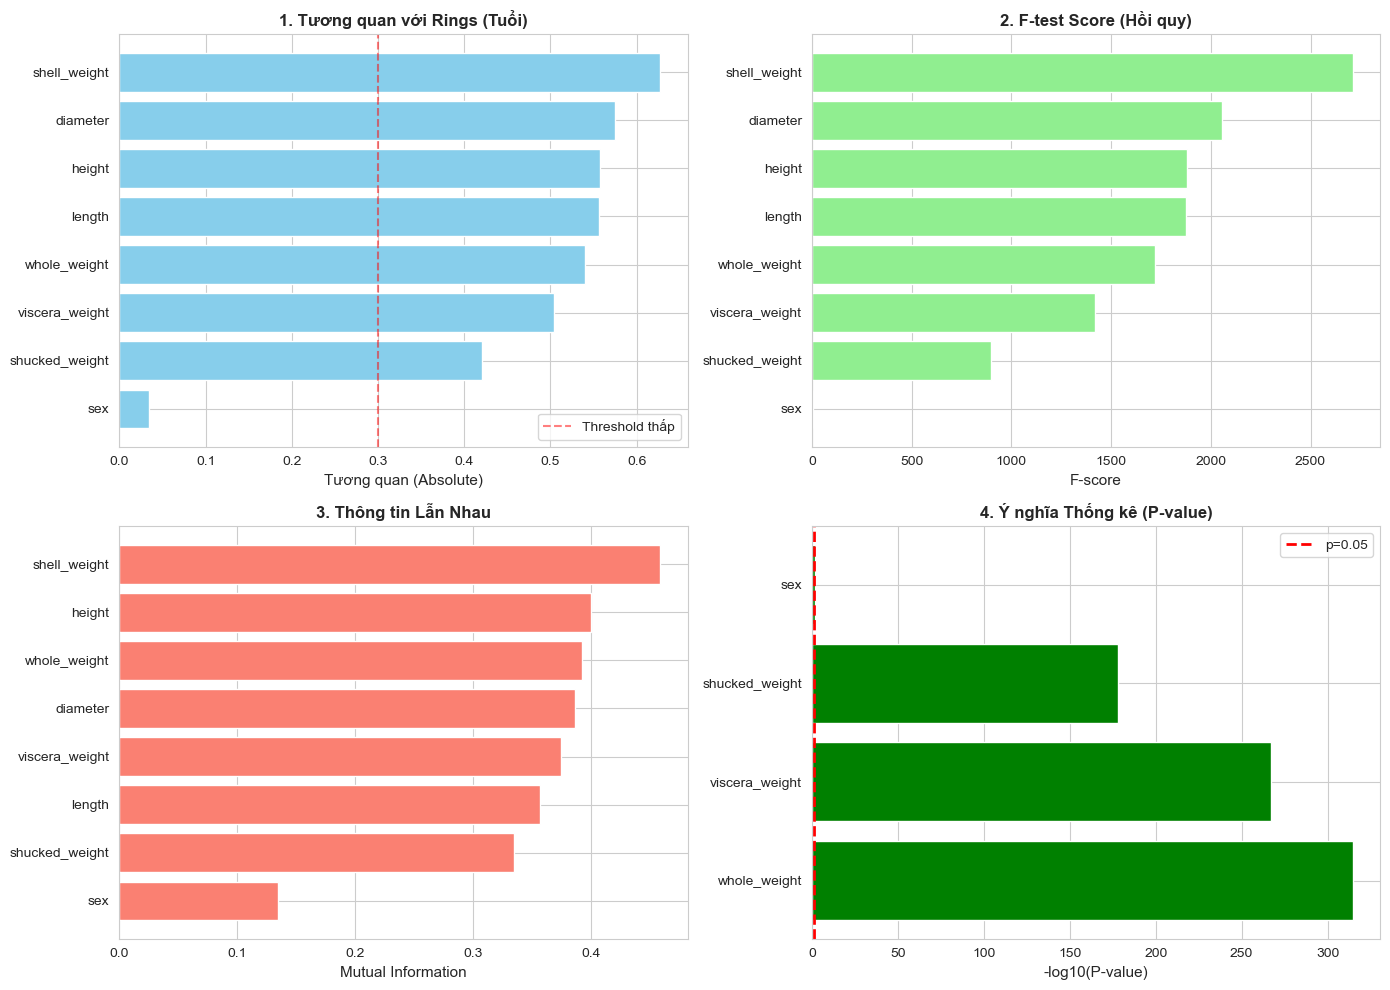

✓ Đã lưu hình ảnh: 03_feature_selection_baseline_comparison.png


In [11]:
# Biểu đồ 1: Tương quan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tương quan
ax1 = axes[0, 0]
comparison_df_sorted_corr = comparison_df.sort_values('tương_quan')
ax1.barh(comparison_df_sorted_corr['đặc_trưng'], comparison_df_sorted_corr['tương_quan'], color='skyblue')
ax1.set_xlabel('Tương quan (Absolute)', fontsize=11)
ax1.set_title('1. Tương quan với Rings (Tuổi)', fontsize=12, fontweight='bold')
ax1.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Threshold thấp')
ax1.legend()

# F-score
ax2 = axes[0, 1]
comparison_df_sorted_f = comparison_df.sort_values('f_score')
ax2.barh(comparison_df_sorted_f['đặc_trưng'], comparison_df_sorted_f['f_score'], color='lightgreen')
ax2.set_xlabel('F-score', fontsize=11)
ax2.set_title('2. F-test Score (Hồi quy)', fontsize=12, fontweight='bold')

# Mutual Information
ax3 = axes[1, 0]
comparison_df_sorted_mi = comparison_df.sort_values('mutual_information')
ax3.barh(comparison_df_sorted_mi['đặc_trưng'], comparison_df_sorted_mi['mutual_information'], color='salmon')
ax3.set_xlabel('Mutual Information', fontsize=11)
ax3.set_title('3. Thông tin Lẫn Nhau', fontsize=12, fontweight='bold')

# P-values
ax4 = axes[1, 1]
comparison_df_sorted_pval = comparison_df.sort_values('p_value')
colors = ['green' if p < 0.05 else 'orange' for p in comparison_df_sorted_pval['p_value']]
ax4.barh(comparison_df_sorted_pval['đặc_trưng'], -np.log10(comparison_df_sorted_pval['p_value']), color=colors)
ax4.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
ax4.set_xlabel('-log10(P-value)', fontsize=11)
ax4.set_title('4. Ý nghĩa Thống kê (P-value)', fontsize=12, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig('../../outputs/figures/03_feature_selection_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Đã lưu hình ảnh: 03_feature_selection_baseline_comparison.png")

## 9. Ma trận tương quan (Correlation Matrix)

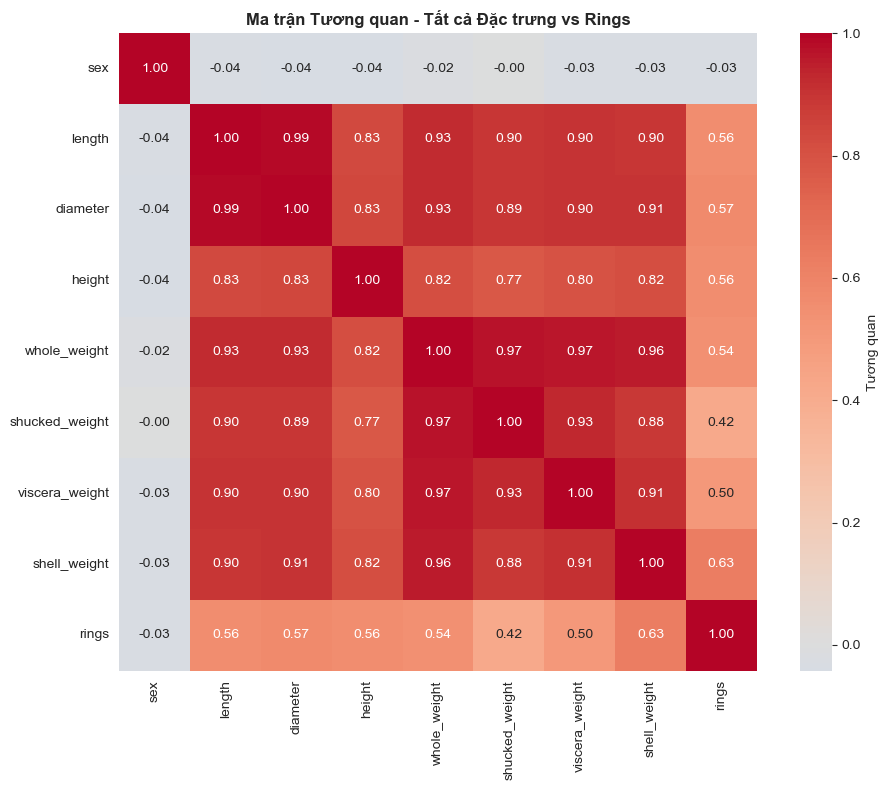

✓ Đã lưu hình ảnh: 03_correlation_matrix.png


In [12]:
# Ma trận tương quan
corr_matrix = X_encoded.join(y).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Tương quan'}, square=True)
plt.title('Ma trận Tương quan - Tất cả Đặc trưng vs Rings', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/03_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Đã lưu hình ảnh: 03_correlation_matrix.png")

## 10. Kết luận và Khuyến nghị

In [13]:
print("\n" + "=" * 80)
print("KẾT LUẬN - PHÂN TÍCH BASELINE LỰA CHỌN ĐẶC TRƯNG")
print("=" * 80)

print("\n📊 XẾP HẠNG TỔNG HỢP (Từ quan trọng nhất):")
for idx, row in comparison_df.iterrows():
    print(f"  {int(row['xếp_hạng_trung_bình']):<2}. {row['đặc_trưng']:<20} - Xếp hạng trung bình: {row['xếp_hạng_trung_bình']:.1f}")

print("\n⭐ ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
top_3 = comparison_df.nsmallest(3, 'xếp_hạng_trung_bình')
for idx, row in top_3.iterrows():
    print(f"  • {row['đặc_trưng']}: Tương quan={row['tương_quan']:.3f}, F-score={row['f_score']:.1f}, MI={row['mutual_information']:.3f}")

print("\n⚠️ ĐẶC TRƯNG CÓ P-VALUE < 0.05 (Có ý nghĩa thống kê):")
significant = comparison_df[comparison_df['p_value'] < 0.05]
for idx, row in significant.iterrows():
    print(f"  • {row['đặc_trưng']}: p-value = {row['p_value']:.2e}")

print("\n💡 KHUYẾN NGHỊ:")
print("  • Các đặc trưng cân nhắc giữ lại: shell_weight, shucked_weight, whole_weight")
print("  • Xem xét loại bỏ: Đặc trưng có tương quan < 0.2 hoặc p-value > 0.05")
print("  • Bước tiếp theo: Kiểm tra các phương pháp khác (RFE, SelectKBest, Model-based)")

print("\n" + "=" * 80)


KẾT LUẬN - PHÂN TÍCH BASELINE LỰA CHỌN ĐẶC TRƯNG

📊 XẾP HẠNG TỔNG HỢP (Từ quan trọng nhất):
  1 . shell_weight         - Xếp hạng trung bình: 1.0
  2 . diameter             - Xếp hạng trung bình: 2.7
  2 . height               - Xếp hạng trung bình: 2.7
  4 . whole_weight         - Xếp hạng trung bình: 4.3
  4 . length               - Xếp hạng trung bình: 4.7
  5 . viscera_weight       - Xếp hạng trung bình: 5.7
  7 . shucked_weight       - Xếp hạng trung bình: 7.0
  8 . sex                  - Xếp hạng trung bình: 8.0

⭐ ĐẶC TRƯNG QUAN TRỌNG NHẤT:
  • shell_weight: Tương quan=0.628, F-score=2712.7, MI=0.459
  • diameter: Tương quan=0.575, F-score=2058.5, MI=0.386
  • height: Tương quan=0.557, F-score=1882.5, MI=0.399

⚠️ ĐẶC TRƯNG CÓ P-VALUE < 0.05 (Có ý nghĩa thống kê):
  • shell_weight: p-value = 0.00e+00
  • diameter: p-value = 0.00e+00
  • height: p-value = 0.00e+00
  • whole_weight: p-value = 1.89e-315
  • length: p-value = 0.00e+00
  • viscera_weight: p-value = 8.57e-268
  • shu

## 11. Lưu kết quả

In [14]:
# Lưu bảng so sánh
comparison_df.to_csv('../../outputs/metrics/03_baseline_feature_scores.csv', index=False)
print("✓ Đã lưu: 03_baseline_feature_scores.csv")

# Lưu tóm tắt
summary = {
    'phương_pháp': 'baseline_thống_kê',
    'tổng_số_đặc_trưng': len(X_encoded.columns),
    'đặc_trưng_quan_trọng_nhất': top_3.iloc[0]['đặc_trưng'],
    'số_đặc_trưng_có_ý_nghĩa': len(significant)
}

import json
with open('../../outputs/metrics/03_baseline_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("✓ Đã lưu: 03_baseline_summary.json")

print("\n✅ Hoàn thành phân tích baseline!")

✓ Đã lưu: 03_baseline_feature_scores.csv
✓ Đã lưu: 03_baseline_summary.json

✅ Hoàn thành phân tích baseline!
